# UAV Unit HR & Operations Analytics — Python/Pandas Deep Dive

This notebook recreates the project's key findings using **pandas, matplotlib, and seaborn** — the Python side of a project originally analyzed with SQL and visualized in Tableau ([see dashboards](https://public.tableau.com/app/profile/islam.rahimov)).

Dataset: 525 personnel across 5 departments (Alpha, Beta, Delta, Gamma, Sigma) of a fictional UAV unit, 2021–2026. All data is synthetic.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
DEPT_ORDER = ['Alpha', 'Beta', 'Delta', 'Gamma', 'Sigma']

personal = pd.read_csv('personal.csv')
medals = pd.read_csv('medals.csv')
risk = pd.read_csv('risk_score.csv')
shoot = pd.read_csv('shooting_performance.csv')
maint = pd.read_csv('aircraft_monthly_maintenance.csv')
tech = pd.read_csv('mission_technical_log.csv')
flight = pd.read_csv('flight_operations.csv')

print(f"Personnel: {len(personal)} | Medals: {len(medals)} | Shots: {len(shoot)} | Missions: {len(tech)}")

Personnel: 525 | Medals: 871 | Shots: 2846 | Missions: 5032


## Finding 1: The Sigma Paradox — Reward System Inequity

Does Sigma department get fewer medals *because* it performs worse, or *despite* performing better? We compare average risk score (lower = safer/better) against average medals per person.

Sigma risk score: 48.2 (lowest of all departments)
Sigma avg medals: 1.18 (lowest of all departments)
Gap vs best-rewarded dept (Beta): 0.73 fewer medals/person


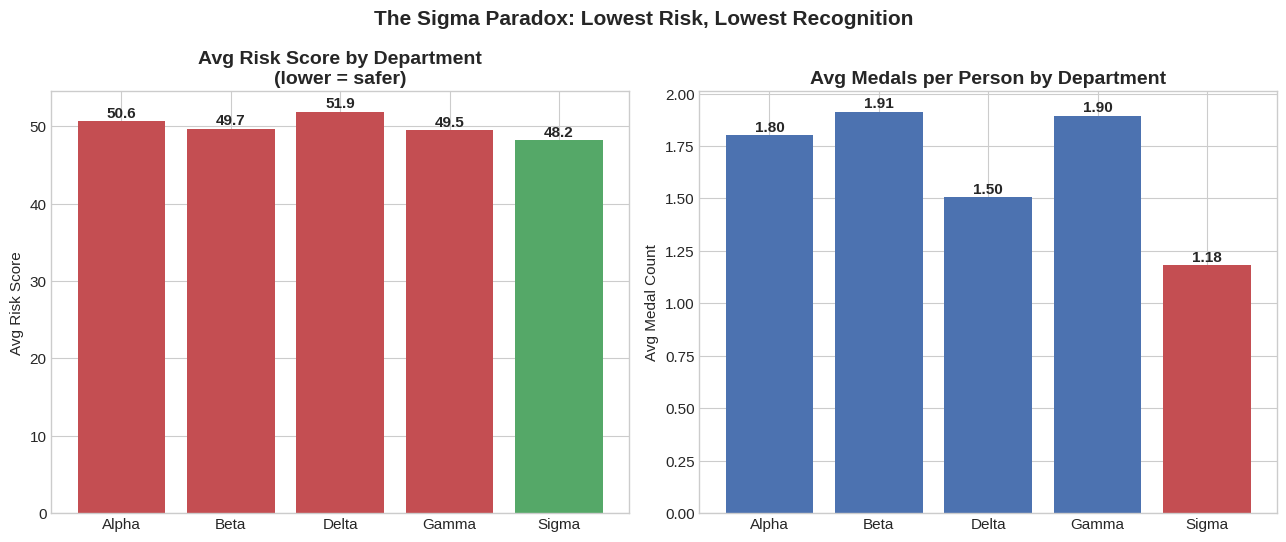

In [2]:
medal_counts = medals.groupby('person_id').size().rename('medal_count')
per_person = personal[['person_id','department']].merge(medal_counts, on='person_id', how='left').fillna({'medal_count':0})

risk_by_dept = risk.groupby('department')['risk_score'].mean().reindex(DEPT_ORDER)
medals_by_dept = per_person.groupby('department')['medal_count'].mean().reindex(DEPT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

colors1 = ['#C44E52' if d != 'Sigma' else '#55A868' for d in DEPT_ORDER]
axes[0].bar(DEPT_ORDER, risk_by_dept.values, color=colors1)
axes[0].set_title('Avg Risk Score by Department\n(lower = safer)')
axes[0].set_ylabel('Avg Risk Score')
for i, v in enumerate(risk_by_dept.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

colors2 = ['#4C72B0' if d != 'Sigma' else '#C44E52' for d in DEPT_ORDER]
axes[1].bar(DEPT_ORDER, medals_by_dept.values, color=colors2)
axes[1].set_title('Avg Medals per Person by Department')
axes[1].set_ylabel('Avg Medal Count')
for i, v in enumerate(medals_by_dept.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

fig.suptitle('The Sigma Paradox: Lowest Risk, Lowest Recognition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Sigma risk score: {risk_by_dept['Sigma']:.1f} (lowest of all departments)")
print(f"Sigma avg medals: {medals_by_dept['Sigma']:.2f} (lowest of all departments)")
print(f"Gap vs best-rewarded dept (Beta): {medals_by_dept['Beta'] - medals_by_dept['Sigma']:.2f} fewer medals/person")

## Finding 2: First-Shot Effect

Does live-fire experience matter more than training? We compare shooting success on a person's *first* live shot vs. all *subsequent* shots.

First shot success rate: 58.1%
Later shots success rate: 87.6%
Improvement: +29.5 percentage points after first live shot


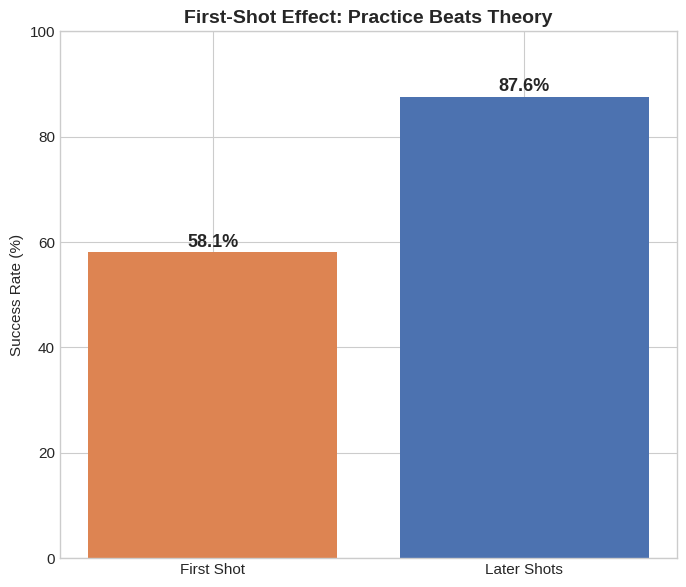

In [3]:
shoot['success'] = (shoot['outcome'] == 'Successful').astype(int)
first_vs_later = shoot.groupby('is_first_shot')['success'].mean() * 100
first_vs_later.index = ['Later Shots', 'First Shot']
first_vs_later = first_vs_later.reindex(['First Shot', 'Later Shots'])

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(first_vs_later.index, first_vs_later.values, color=['#DD8452', '#4C72B0'])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Success Rate (%)')
ax.set_title('First-Shot Effect: Practice Beats Theory', fontweight='bold')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"First shot success rate: {first_vs_later['First Shot']:.1f}%")
print(f"Later shots success rate: {first_vs_later['Later Shots']:.1f}%")
print(f"Improvement: +{first_vs_later['Later Shots'] - first_vs_later['First Shot']:.1f} percentage points after first live shot")

## Finding 3: Simpson's Paradox — When Aggregation Lies

At the **department-year** level, more maintenance hours correlate with *more* technical problems. But is maintenance actually causing problems? We re-check the same relationship at the **individual aircraft-month** level.

Department-year correlation: +0.112
Aircraft-month correlation:  -0.004
Hidden confounder: fleet aging. Older departments fly more AND need more maintenance,
which creates a spurious positive link at the aggregate level.


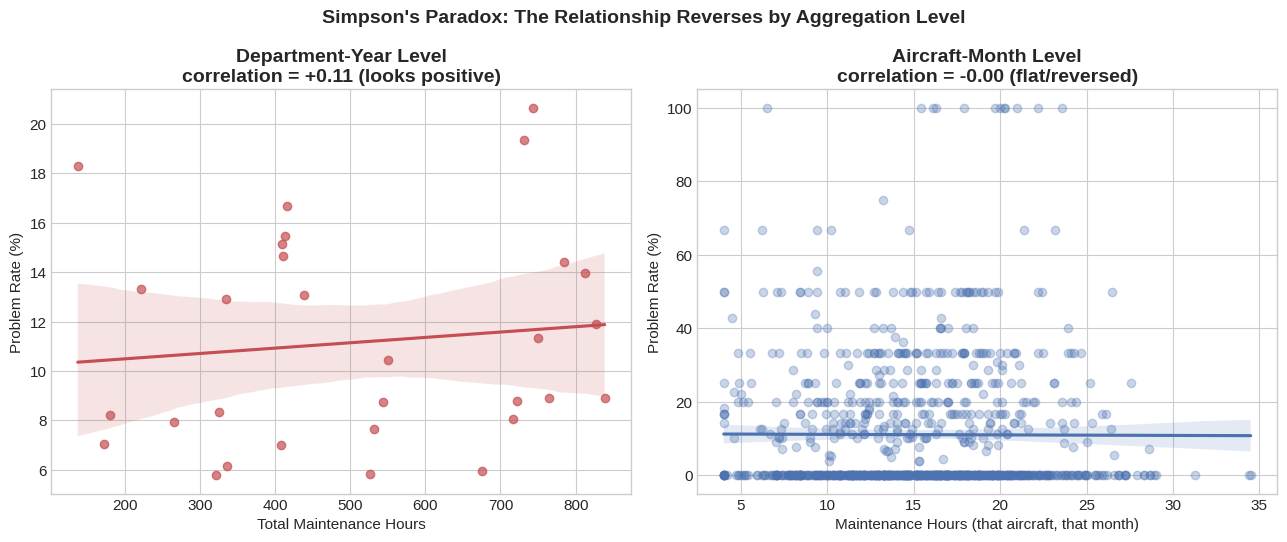

In [4]:
# Department-year level (aggregated)
maint_dy = maint.groupby(['department','year'])['maintenance_hours'].sum().reset_index()
prob_dy = tech.groupby(['department','year']).agg(
    total_missions=('mission_id','count'),
    problems=('had_inflight_technical_problem','sum')
).reset_index()
prob_dy['problem_rate'] = prob_dy['problems'] / prob_dy['total_missions'] * 100
dy = maint_dy.merge(prob_dy, on=['department','year'])
corr_dy = dy['maintenance_hours'].corr(dy['problem_rate'])

# Aircraft-month level (individual)
prob_am = tech.groupby(['aircraft_id','year','month']).agg(
    total_missions=('mission_id','count'),
    problems=('had_inflight_technical_problem','sum')
).reset_index()
prob_am['problem_rate'] = prob_am['problems'] / prob_am['total_missions'] * 100
am = maint[['aircraft_id','year','month','maintenance_hours']].merge(prob_am, on=['aircraft_id','year','month'])
corr_am = am['maintenance_hours'].corr(am['problem_rate'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.regplot(data=dy, x='maintenance_hours', y='problem_rate', ax=axes[0],
            scatter_kws={'color':'#C44E52','alpha':0.7}, line_kws={'color':'#C44E52'})
axes[0].set_title(f'Department-Year Level\ncorrelation = {corr_dy:+.2f} (looks positive)')
axes[0].set_xlabel('Total Maintenance Hours')
axes[0].set_ylabel('Problem Rate (%)')

sns.regplot(data=am, x='maintenance_hours', y='problem_rate', ax=axes[1],
            scatter_kws={'color':'#4C72B0','alpha':0.3}, line_kws={'color':'#4C72B0'})
axes[1].set_title(f'Aircraft-Month Level\ncorrelation = {corr_am:+.2f} (flat/reversed)')
axes[1].set_xlabel('Maintenance Hours (that aircraft, that month)')
axes[1].set_ylabel('Problem Rate (%)')

fig.suptitle("Simpson's Paradox: The Relationship Reverses by Aggregation Level", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Department-year correlation: {corr_dy:+.3f}")
print(f"Aircraft-month correlation:  {corr_am:+.3f}")
print("Hidden confounder: fleet aging. Older departments fly more AND need more maintenance,")
print("which creates a spurious positive link at the aggregate level.")

## Finding 4: Aircraft Reliability Declines With Age

In-flight technical problem rate, binned by aircraft age (years since entering service).

Problem rate at age 0: 9.1%
Problem rate at oldest tracked age (6): 10.1%
Supports proactive fleet-replacement planning around the 4-5 year mark.


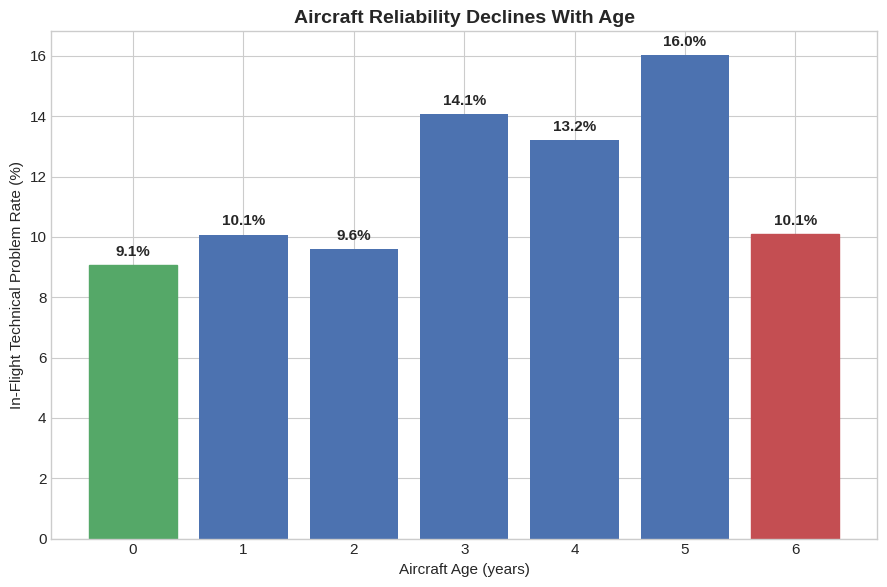

In [5]:
tech['age_bucket'] = tech['aircraft_age_years'].round().astype(int)
age_agg = tech.groupby('age_bucket').agg(
    total=('mission_id','count'),
    problems=('had_inflight_technical_problem','sum')
)
age_agg['problem_rate'] = age_agg['problems'] / age_agg['total'] * 100
age_agg = age_agg[age_agg['total'] >= 50]  # drop sparse tail

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(age_agg.index.astype(str), age_agg['problem_rate'], color='#4C72B0')
bars[0].set_color('#55A868')
bars[len(bars)-1].set_color('#C44E52')
for i, (idx, row) in enumerate(age_agg.iterrows()):
    ax.text(i, row['problem_rate'] + 0.3, f"{row['problem_rate']:.1f}%", ha='center', fontweight='bold')
ax.set_xlabel('Aircraft Age (years)')
ax.set_ylabel('In-Flight Technical Problem Rate (%)')
ax.set_title('Aircraft Reliability Declines With Age', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Problem rate at age 0: {age_agg['problem_rate'].iloc[0]:.1f}%")
print(f"Problem rate at oldest tracked age ({age_agg.index[-1]}): {age_agg['problem_rate'].iloc[-1]:.1f}%")
print("Supports proactive fleet-replacement planning around the 4-5 year mark.")

## Finding 5: Methodology Matters — Rank vs. Flight Hours

Does flight activity decline with rank? The answer depends entirely on *how* you measure "flight hours." We compare **lifetime cumulative hours** against **last-12-months hours**.

                    cumulative_hours  last12_hours
rank                                              
Lieutenant                     813.1         372.9
Senior Lieutenant             2030.7         326.5
Captain                       1782.5         256.1
Major                         1800.4         200.6
Lieutenant Colonel            2734.4         231.1

Lieutenants fly the most in any recent 12-month window; Lt. Colonels fly the least —
a pattern completely invisible when only cumulative career totals are examined.


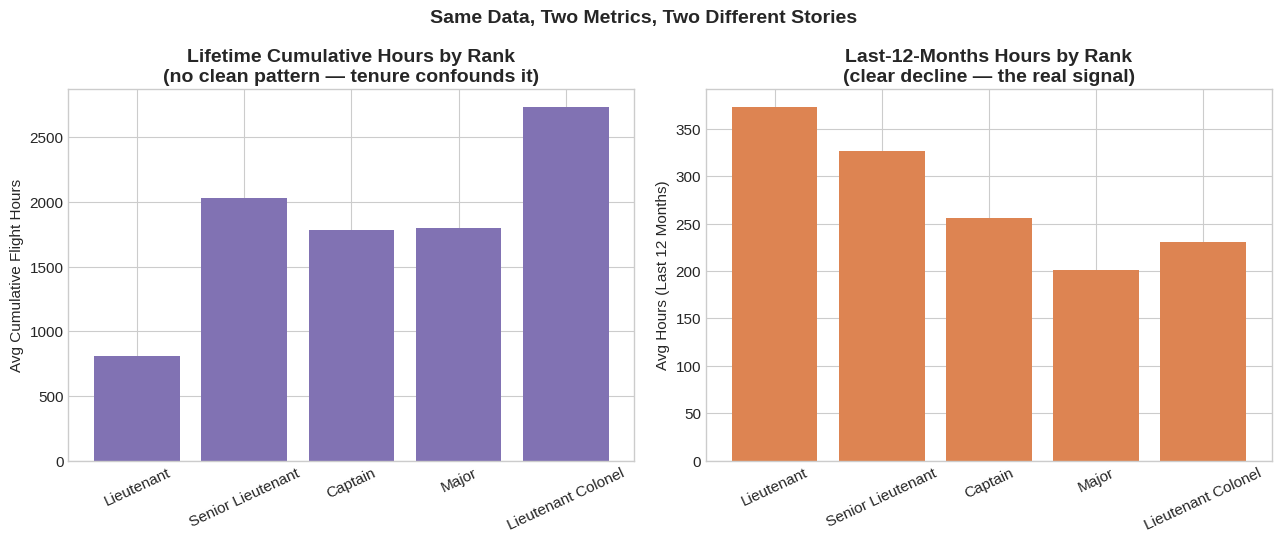

In [6]:
flight['total_hours'] = flight[['flight_hours_real','flight_hours_training','flight_hours_combat','flight_hours_test']].sum(axis=1)
personal_rank = personal[['person_id','rank']]

cum = flight.groupby('person_id')['total_hours'].sum().rename('cumulative_hours')

flight['ym'] = flight['year'] * 12 + flight['month']
max_ym = flight['ym'].max()
last12 = flight[flight['ym'] > max_ym - 12]
last12_sum = last12.groupby('person_id')['total_hours'].sum().rename('last12_hours')

merged = personal_rank.merge(cum, on='person_id', how='left').merge(last12_sum, on='person_id', how='left').fillna(0)

rank_order = ['Lieutenant','Senior Lieutenant','Captain','Major','Lieutenant Colonel']
by_rank = merged[merged['rank'].isin(rank_order)].groupby('rank')[['cumulative_hours','last12_hours']].mean().reindex(rank_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].bar(rank_order, by_rank['cumulative_hours'], color='#8172B3')
axes[0].set_title('Lifetime Cumulative Hours by Rank\n(no clean pattern — tenure confounds it)')
axes[0].set_ylabel('Avg Cumulative Flight Hours')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(rank_order, by_rank['last12_hours'], color='#DD8452')
axes[1].set_title('Last-12-Months Hours by Rank\n(clear decline — the real signal)')
axes[1].set_ylabel('Avg Hours (Last 12 Months)')
axes[1].tick_params(axis='x', rotation=25)

fig.suptitle('Same Data, Two Metrics, Two Different Stories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(by_rank.round(1))
print()
print("Lieutenants fly the most in any recent 12-month window; Lt. Colonels fly the least —")
print("a pattern completely invisible when only cumulative career totals are examined.")

## Finding 6: Is the Sigma Paradox Statistically Significant?

The bar charts in Finding 1 show Sigma has the lowest risk score and fewest medals — but is that a real, statistically robust difference, or could it be random noise in a 525-person sample? An independent-samples **t-test** answers that.

Risk score:   Sigma mean=48.2 vs Other mean=50.4  ->  p=0.067
Medal count:  Sigma mean=1.18 vs Other mean=1.78  ->  p=0.0011

The medal gap is statistically significant (p<0.01) — Sigma is genuinely under-recognized,
not just unlucky in a small sample. The risk-score gap is only marginal (p~0.07) —
real, but weaker evidence. This distinction matters: it tells leadership which claim to
act on with confidence and which one needs more data before treating it as fact.


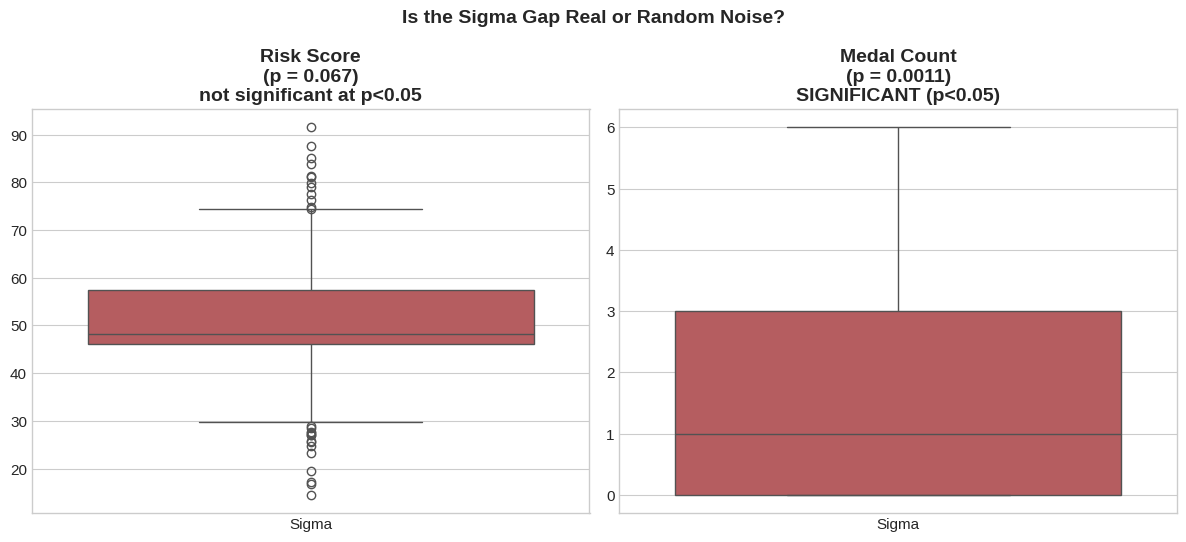

In [7]:
from scipy import stats

personal = pd.read_csv('personal.csv')[['person_id','department']]
medals = pd.read_csv('medals.csv')
risk = pd.read_csv('risk_score.csv')

# Test 1: risk score, Sigma vs. everyone else
sigma_risk = risk[risk['department']=='Sigma']['risk_score']
other_risk = risk[risk['department']!='Sigma']['risk_score']
t1, p1 = stats.ttest_ind(sigma_risk, other_risk)

# Test 2: medal count, Sigma vs. everyone else
medal_counts = medals.groupby('person_id').size().rename('medal_count')
per_person = personal.merge(medal_counts, on='person_id', how='left').fillna({'medal_count':0})
sigma_medals = per_person[per_person['department']=='Sigma']['medal_count']
other_medals = per_person[per_person['department']!='Sigma']['medal_count']
t2, p2 = stats.ttest_ind(sigma_medals, other_medals)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data_a, data_b, title, p in [
    (axes[0], sigma_risk, other_risk, f'Risk Score\n(p = {p1:.3f})', p1),
    (axes[1], sigma_medals, other_medals, f'Medal Count\n(p = {p2:.4f})', p2),
]:
    sns.boxplot(data=[data_a, data_b], ax=ax, palette=['#C44E52','#4C72B0'])
    ax.set_xticklabels(['Sigma', 'Other Depts'])
    sig_label = 'SIGNIFICANT (p<0.05)' if p < 0.05 else 'not significant at p<0.05'
    ax.set_title(f'{title}\n{sig_label}')

fig.suptitle('Is the Sigma Gap Real or Random Noise?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Risk score:   Sigma mean={sigma_risk.mean():.1f} vs Other mean={other_risk.mean():.1f}  ->  p={p1:.3f}")
print(f"Medal count:  Sigma mean={sigma_medals.mean():.2f} vs Other mean={other_medals.mean():.2f}  ->  p={p2:.4f}")
print()
print("The medal gap is statistically significant (p<0.01) — Sigma is genuinely under-recognized,")
print("not just unlucky in a small sample. The risk-score gap is only marginal (p~0.07) —")
print("real, but weaker evidence. This distinction matters: it tells leadership which claim to")
print("act on with confidence and which one needs more data before treating it as fact.")

## Finding 7: What Predicts High Risk? (Logistic Regression)

Instead of describing patterns after the fact, can we predict who's likely to be flagged high-risk *before* it happens? A logistic regression trained on operational metrics (success rate, flight hours, medals, tenure) answers that — and its coefficients reveal which factors matter most.

Base rate: 9.7% of personnel are flagged high-risk
Model ROC AUC: 0.768 (0.5 = random guessing, 1.0 = perfect)

Strongest predictor: LOW success_rate is the single biggest driver of high-risk status.
Flight hours and tenure have a smaller positive effect — more exposure, slightly more risk.
Practical use: flag personnel with declining success rate for early intervention,
rather than waiting for the risk score to already cross the threshold.


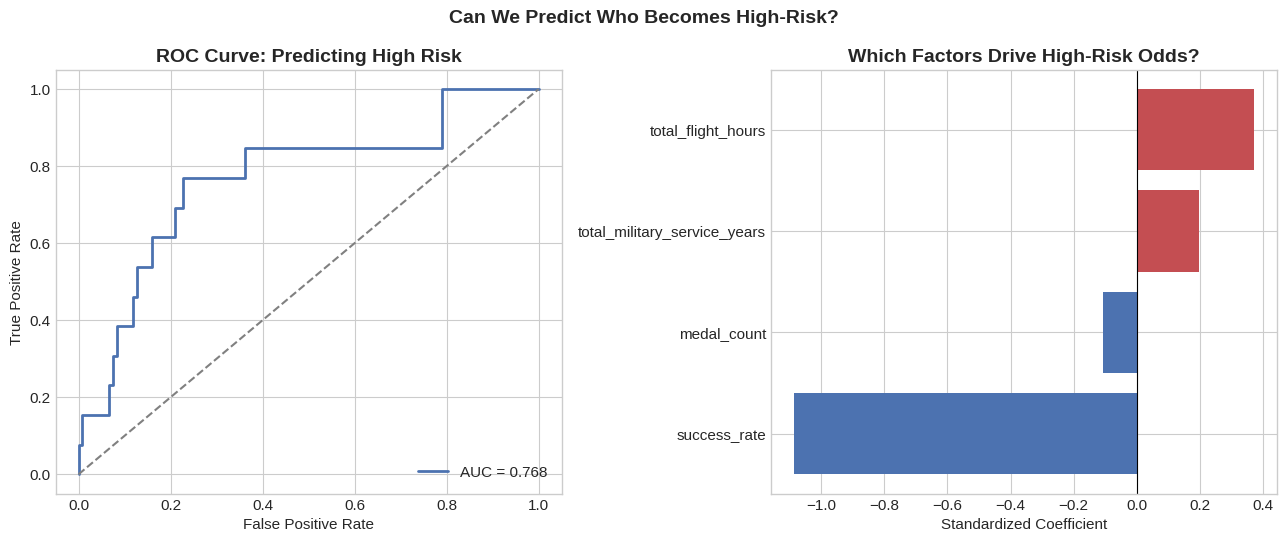

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

risk = pd.read_csv('risk_score.csv')
medals = pd.read_csv('medals.csv')
shoot = pd.read_csv('shooting_performance.csv')
flight = pd.read_csv('flight_operations.csv')
personal = pd.read_csv('personal.csv')[['person_id','total_military_service_years']]

shoot['success'] = (shoot['outcome']=='Successful').astype(int)
success_rate = shoot.groupby('person_id')['success'].mean().rename('success_rate')
medal_counts = medals.groupby('person_id').size().rename('medal_count')
flight['total_hours'] = flight[['flight_hours_real','flight_hours_training','flight_hours_combat','flight_hours_test']].sum(axis=1)
total_flight = flight.groupby('person_id')['total_hours'].sum().rename('total_flight_hours')

df = risk[['person_id','risk_score']].merge(success_rate, on='person_id', how='left')
df = df.merge(medal_counts, on='person_id', how='left').fillna({'medal_count':0})
df = df.merge(total_flight, on='person_id', how='left').fillna({'total_flight_hours':0})
df = df.merge(personal, on='person_id', how='left')
df['success_rate'] = df['success_rate'].fillna(df['success_rate'].mean())
df['high_risk'] = (df['risk_score'] >= 65).astype(int)

feat_cols = ['success_rate','medal_count','total_flight_hours','total_military_service_years']
X = StandardScaler().fit_transform(df[feat_cols])
y = df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

coefs = sorted(zip(feat_cols, model.coef_[0]), key=lambda x: x[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Predicting High Risk')
axes[0].legend(loc='lower right')

feat_names = [c[0] for c in coefs]
feat_vals = [c[1] for c in coefs]
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in feat_vals]
axes[1].barh(feat_names, feat_vals, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Which Factors Drive High-Risk Odds?')
axes[1].set_xlabel('Standardized Coefficient')

fig.suptitle('Can We Predict Who Becomes High-Risk?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Base rate: {y.mean()*100:.1f}% of personnel are flagged high-risk")
print(f"Model ROC AUC: {auc:.3f} (0.5 = random guessing, 1.0 = perfect)")
print()
print("Strongest predictor: LOW success_rate is the single biggest driver of high-risk status.")
print("Flight hours and tenure have a smaller positive effect — more exposure, slightly more risk.")
print("Practical use: flag personnel with declining success rate for early intervention,")
print("rather than waiting for the risk score to already cross the threshold.")

## Summary

| Finding | Key Number |
|---|---|
| Sigma Paradox | Lowest risk score (48.2) **and** lowest medals/person (1.18) |
| First-shot effect | 58.1% → 87.6% success after first live shot |
| Simpson's Paradox | +0.11 correlation (dept-year) reverses to ~0.00 (aircraft-month) |
| Aircraft aging | Problem rate roughly doubles from age 0 to age 5 |
| Rank vs. flight hours | Cumulative hours hide a decline that last-12-months reveals |
| **Statistical test (new)** | Sigma's medal gap is significant (p<0.01); the risk-score gap is only marginal (p≈0.07) |
| **Predictive model (new)** | Logistic regression predicts high-risk status with AUC=0.77 — low success rate is the strongest driver |

Full write-up with SQL queries and Tableau dashboards: [PROJECT_INSIGHTS.md](../docs/PROJECT_INSIGHTS.md) · [Tableau Public dashboards](https://public.tableau.com/app/profile/islam.rahimov)